### **Plotting the Implied Volatility surface for SPY options**

In [39]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from datetime import datetime, timezone
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
ticker = 'SPY'
tkr = yf.Ticker(ticker)

In [41]:
# ---------- HELPER FUNCTIONS ----------

# Black-Scholes pricer function
def bs_price(S, K, T, r, q, sigma, is_call=True):
    '''
    Calculates the Black-Scholes price for a given set of inputs from the option chain data
    '''

    if T<=0 or sigma<=0:
        return np.nan
    F = S*np.exp(-(r-q)*T)          # Forward price
    df = np.exp(-r*T)               # Discount Factor

    vol_sqrtT = sigma*np.sqrt(T)    # Denominators for d_1 and d_2
    d1 = (np.log(F/K)+0.5*(sigma*sigma)*T)/vol_sqrtT
    d2 = d1 - vol_sqrtT

    if is_call:
        return df*(F*norm.cdf(d1)-K*norm.cdf(d2))
    else: 
        return df*(K*norm.cdf(-d2)-F*norm.cdf(-d1))

# Implied Vol solver
def implied_vol(price, S, K, T, r, q, is_call=True):
    '''
    Using the BrentQ method of root finding:
    - BrentQ method offers a better solution to rootfinding incase 
      we don't have a close rough estimate of the initial value of the root.
    
    Calculting the IV for the given option chain: Solve for sigma such that 
    the BS price matches the given option price
    '''

    if price<=0 or T<=0 or K<=0 or S<=0:
        return np.nan

    # Objective function in sigma????
    f = lambda sig: bs_price(S, K, T, r, q, sig, is_call) - price

    try: 
        return brentq(f, 1e-6, 5.0)     # Sigma in range(0%, 500%)
    except ValueError:
        return np.nan

In [42]:
# Pulling Option chain data
S0 = tkr.history(period='1d')['Close'].iloc[-1]         # Spot Proxy: using this as the Spot for generating the vol surface
expiries = tkr.options[:10]                             # Taking the first 10 expiries

rows = []

now = datetime.now(timezone.utc)                        # Current time

for exp in expiries:
    chain = tkr.option_chain(exp)

    for opt_type, df in [('call', chain.calls), ('put', chain.puts)]:
        df = df.copy()
        df['type'] = opt_type
        df['expiry'] = exp
        rows.append(df)

opt = pd.concat(rows, ignore_index = True)

In [43]:
# Keeping only usable bid/ask quotes
opt = opt.dropna(subset=['strike', 'bid', 'ask'])
opt = opt[(opt['bid']>0) & (opt['ask']>0)]                  # Valid quotes where the price is positive
opt['mid'] = 0.5*(opt['bid'] +opt['ask'])                   # Using mid-price for implied vol calculation(is this valid??)

# Calculating the Time to Expiry(years)
expt_dt = pd.to_datetime(opt['expiry']).dt.tz_localize('UTC')
opt['T'] = (expt_dt-now).dt.total_seconds()/(365*24*3600)  # Converting to decimals
opt = opt[opt['T']>0]                                      # Selecting the options with future expiries only

In [44]:
# Sample risk-free rate and dividend yield
r = 0.05
q = 0.00

In [45]:
# Computing implied vol for each row
opt['is_call'] = (opt['type']=='call')

opt['iv_cal'] = opt.apply(
    lambda row: implied_vol(
        price = row['mid'],
        S = S0, 
        K = row['strike'],
        T = row['T'],
        r = r,
        q = q,
        is_call = row['is_call']
    ),
    axis = 1
)

opt = opt.dropna(subset=['iv_cal'])
opt = opt[(opt['iv_cal'] > 0) & (opt['iv_cal']<3.0)]    # Keeping sane values of volatility

In [46]:
# Converting to Surface cooridinates
opt['k'] = np.log(opt['strike']/S0)         # Log moneyness = log(K/S)
opt['iv'] = opt['iv_cal']                   # Just creating another row that I can use in the plot

opt

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,contractSize,currency,type,expiry,mid,T,is_call,iv_cal,k,iv
0,SPY260112C00550000,2025-12-31 18:45:53+00:00,550.0,136.12,142.60,145.40,0.000000,0.000000,NaN,5.0,...,REGULAR,USD,call,2026-01-12,144.000,0.002943,True,1.578444,-0.232655,1.578444
1,SPY260112C00640000,2026-01-09 17:31:56+00:00,640.0,54.37,52.62,55.41,1.349999,2.546206,280.0,7.0,...,REGULAR,USD,call,2026-01-12,54.015,0.002943,True,0.614002,-0.081105,0.614002
2,SPY260112C00645000,2026-01-09 17:24:43+00:00,645.0,49.88,47.64,50.42,10.700001,27.309853,214.0,3.0,...,REGULAR,USD,call,2026-01-12,49.030,0.002943,True,0.577757,-0.073323,0.577757
3,SPY260112C00650000,2026-01-09 20:57:56+00:00,650.0,44.52,42.64,45.38,10.980000,32.737030,23.0,9.0,...,REGULAR,USD,call,2026-01-12,44.010,0.002943,True,0.501192,-0.065600,0.501192
4,SPY260112C00655000,2025-12-29 15:11:13+00:00,655.0,34.15,37.63,40.43,0.000000,0.000000,NaN,2.0,...,REGULAR,USD,call,2026-01-12,39.030,0.002943,True,0.468620,-0.057938,0.468620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2051,SPY260213P00699000,2026-01-09 21:09:19+00:00,699.0,11.41,11.41,11.46,-8.830000,-43.626480,13.0,0.0,...,REGULAR,USD,put,2026-02-13,11.435,0.090614,False,0.080210,0.007078,0.080210
2052,SPY260213P00700000,2026-01-09 19:04:12+00:00,700.0,11.83,11.89,11.94,-3.230001,-21.447546,7524.0,558.0,...,REGULAR,USD,put,2026-02-13,11.915,0.090614,False,0.077185,0.008508,0.077185
2053,SPY260213P00702000,2026-01-09 20:00:00+00:00,702.0,12.58,11.83,14.02,-3.770001,-23.058105,42.0,43.0,...,REGULAR,USD,put,2026-02-13,12.925,0.090614,False,0.070082,0.011361,0.070082
2054,SPY260213P00704000,2026-01-09 21:03:40+00:00,704.0,13.88,12.29,15.76,-1.960000,-12.373737,4.0,3.0,...,REGULAR,USD,put,2026-02-13,14.025,0.090614,False,0.060898,0.014206,0.060898


In [47]:
# Interpolating this into a grid(Smooth curve)
opt_plot = opt.sample(min(len(opt), 4000), random_state=0)

k_grid = np.linspace(opt_plot['k'].quantile(0.02), opt_plot['k'].quantile(0.98), 60)       # 60 points on the Moneyness axis(X)
T_grid = np.linspace(opt_plot['T'].quantile(0.02), opt_plot['T'].quantile(0.98), 40)       # 40 point on the Expiries exis(Y)

points = np.column_stack([opt_plot['k'].values, opt_plot['T'].values])
values = opt_plot['iv'].values

K, TT = np.meshgrid(k_grid, T_grid)

IV_grid = griddata(points, values, (K, TT), method='linear')

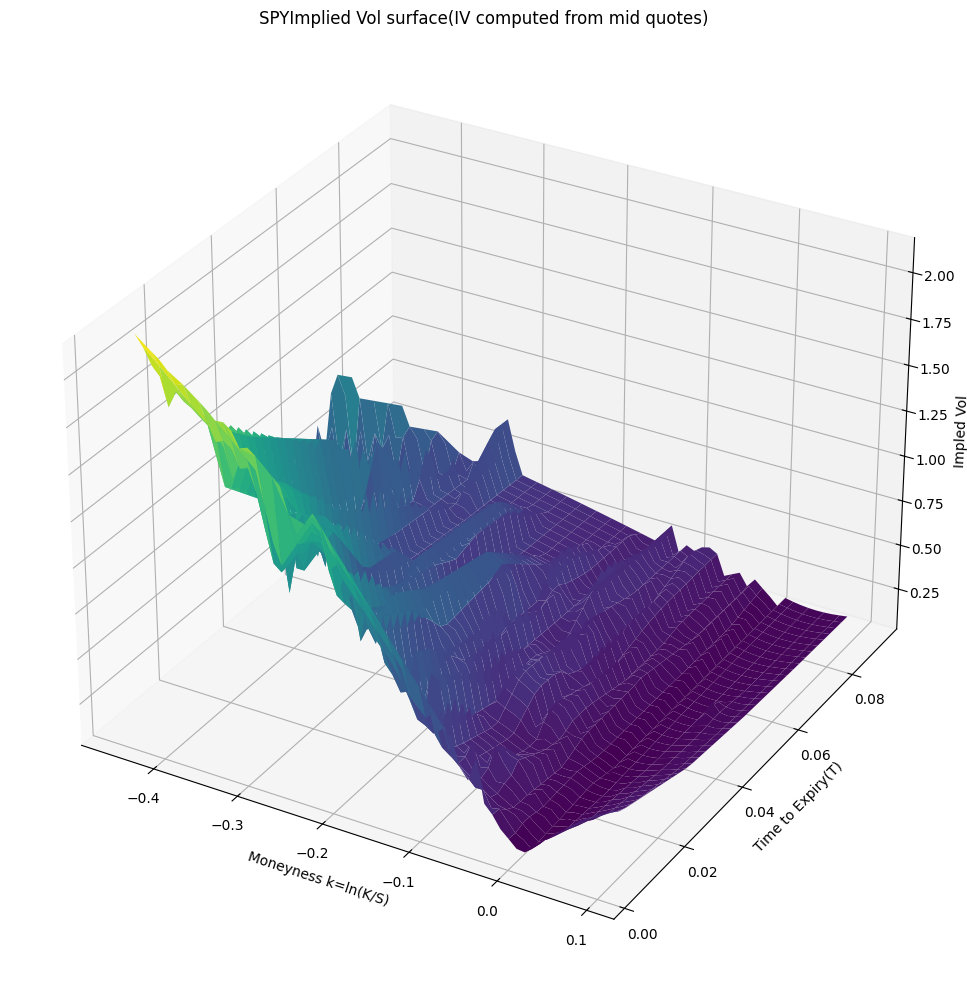

In [48]:
# Plotting the Vol Surface
fig = plt.figure(figsize=(18, 10))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(K, TT, IV_grid, cmap= 'viridis',linewidth = 0, antialiased = True)

ax.set_xlabel("Moneyness k=ln(K/S)")
ax.set_ylabel("Time to Expiry(T)")
ax.set_zlabel("Impled Vol")
ax.set_title(f"{ticker}Implied Vol surface(IV computed from mid quotes)")
plt.tight_layout()
plt.show()

In [49]:
from scipy.interpolate import Rbf

rbf = Rbf(opt_plot["k"].values, opt_plot["T"].values, opt_plot["iv"].values,
          function="multiquadric", smooth=0.02)

IV_rbf = rbf(K, TT)

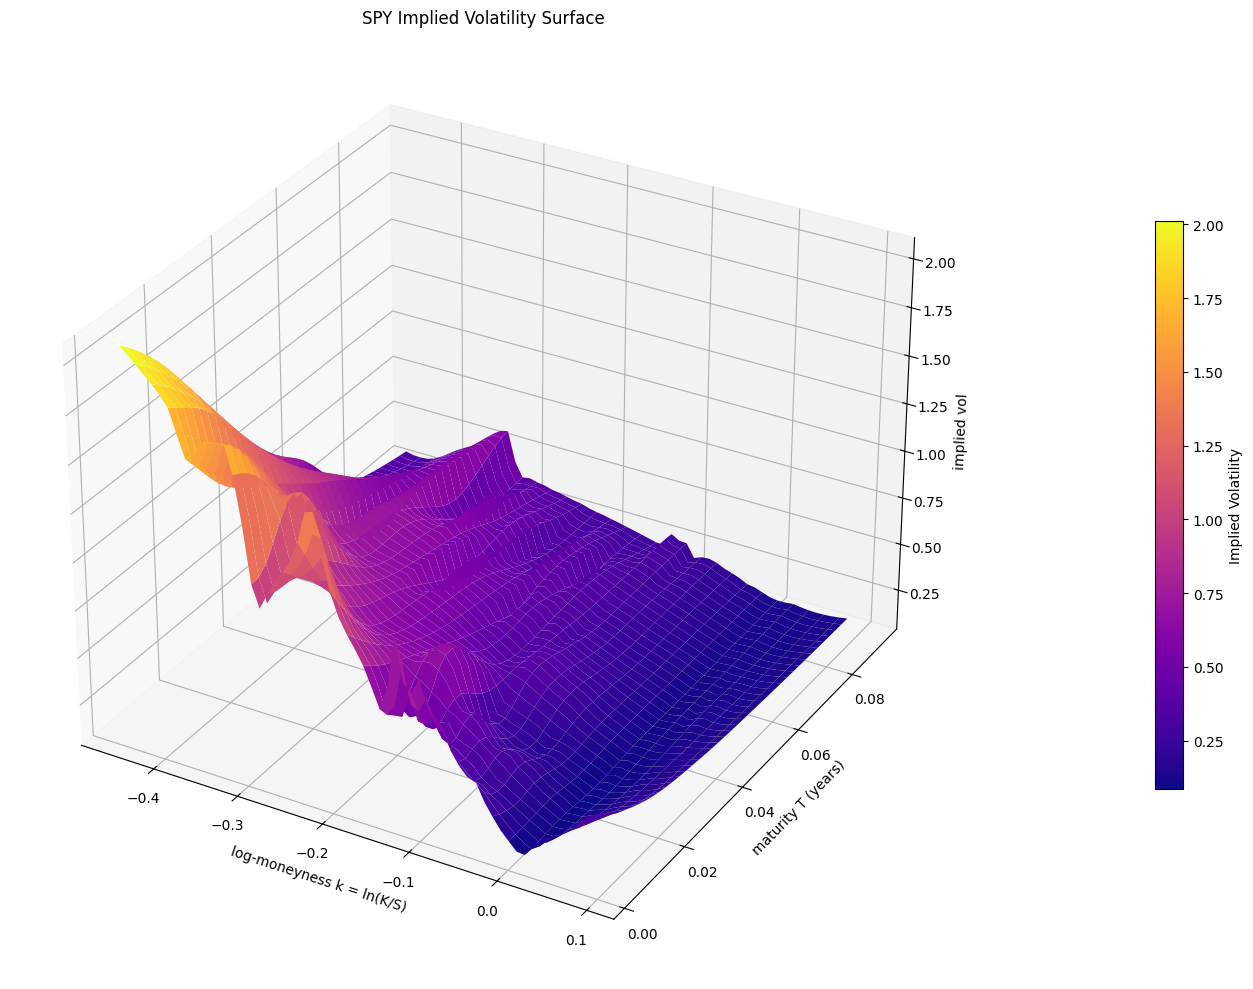

In [ ]:
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    K, TT, IV_rbf,                 
    cmap="plasma",                 
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("log-moneyness k = ln(K/S)")
ax.set_ylabel("maturity T (years)")
ax.set_zlabel("implied vol")
ax.set_title("SPY Implied Volatility Surface")

cbar = fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Implied Volatility")

plt.tight_layout()
plt.show()


#### **Observations:**
1. **Strong Negative skew:** Implied vol is much higher for lower strikes and the skew is steepest at shorted maturities.
Interpretation: Downside risk is much more agressively priced in equities(crash risk).
2. **Short-dated IV explodes on the left tail:** Deep OTM short-dated options have very small prices and even a small change can result in a huge change in IV(enbedded jump risk(earnings, macro events, overnight risk)).
3. **ATM region is smooth and stable:** ATM options remain stable near expiry because they are liquid, continuously repriced, and their implied vol reflects the market’s expectation of integrated variance rather than tail events.


#### **Linear Interpolation**
Linear interpolation estimates implied volatility at an unobserved point \((k,T)\) by constructing a **piecewise linear surface** between nearby observed implied volatility data points. The interpolated surface matches observed values exactly but is not smooth across regions.


#### **Radial Basis Function (RBF) Smoothing**
RBF smoothing represents implied volatility as a **global smooth function**, defined as a weighted sum of radial basis functions centered at observed data points. The resulting surface is continuously differentiable and approximates the data, with a regularization parameter controlling the trade-off between smoothness and fit accuracy.


#### **Key Distinction**
**Linear interpolation** is a local, exact reconstruction method, while **RBF smoothing** is a global, approximate reconstruction method designed to reduce noise and enforce smoothness.


| Aspect | Linear Interpolation (`griddata`, linear) | RBF Smoothing (`Rbf`) |
|------|-------------------------------------------|----------------------|
| Fit type | Piecewise linear between nearby points | Global smooth function |
| Exactness | Matches data locally exactly | Does not match points exactly |
| Noise sensitivity | Very sensitive to noisy / illiquid quotes | Robust to local noise |
| Surface appearance | Spiky, faceted, ridged | Smooth and continuous |
| Smoothness of derivatives | Not smooth (kinks in slope/curvature) | Smooth first & second derivatives |
| Control parameter | None | `smooth` parameter controls regularization |
| Computational cost | Fast | Slower |
| Extrapolation | Poor near edges | Better but still model-free |
| Arbitrage awareness | None | None |
| Typical use | Quick visualization, debugging | Presentation, exploratory analysis |
